# predictive modelling- Loan Approval
In modern times, a lot of people depend on loans from financial institutions, either for the own personal development, businesses, health etc, but the loaning cretia (approval status) depends on a number of factors. We are going to explore these factors to determine or predict whether the next loan application will be approved or not.This is analysis is important for financial instiutions to make decisions when a client applies for a loan. The dependent Variable is Loan_status

In [1]:
import warnings
# Silence the pandas/bottleneck version warning completely
warnings.filterwarnings('ignore', message="Pandas requires version '1.3.6'")
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
#App launching
%load_ext autoreload 
%autoreload 2

In [52]:
#import libraries
import os
import joblib
import glob
#Data Handling
import pandas as pd
import numpy as np
#Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
#Model Building
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from category_encoders import OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.utils.class_weight import compute_sample_weight
import dash
from display import app

# Prepare Data

# Import

We are using a wrangle function to wrangle (clean) the data then import the data into a DataFrame

In [4]:
#data wrangling
def wrangle(filepath):
    #Read data into dataframe
    df=pd.read_csv(filepath)
    #Converting the loan_status 
    df["loan_status"]=df.loan_status.astype(bool)
    #Clustering the ages in the person_age column
    #Define bin boundaries and corresponding labels
    bins = [0, 25, 29,34,39, 44, 49, 54,59,64,69, float('inf')]
    labels = [
        "Under 25", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54","55-59","60-64","65-69","70 and Above"
    ]
    # Create an age_group column
    df['age_group'] = pd.cut(df['person_age'], bins=bins, labels=labels, right=True)
    #Drop the person_age column
    df.drop(columns="person_age",inplace=True)
    
    
    
    return df


In [5]:
#Loading the data
df=wrangle("data/credit_risk_dataset.csv")


# Explore
We will inspect and do visualizations of the DataFrame.

# Inspecting the DataFrame
We use shape to determine the dimension of the datafarame, the info() generates information about the columns i.e column names,data types and the presence/absence of null data, the head(), returns the first 5 rows of the DataFrame. The describe function, gives the summary statistics of the numerical columns of the DataFrame.

In [6]:
#Inspecting the dataframe i.e check the shape, generate information about the data columns,view the first 5 rows od the dataframe
print(df.shape)
df.info()
df.head()

(32581, 12)
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_income               32581 non-null  int64   
 1   person_home_ownership       32581 non-null  str     
 2   person_emp_length           31686 non-null  float64 
 3   loan_intent                 32581 non-null  str     
 4   loan_grade                  32581 non-null  str     
 5   loan_amnt                   32581 non-null  int64   
 6   loan_int_rate               29465 non-null  float64 
 7   loan_status                 32581 non-null  bool    
 8   loan_percent_income         32581 non-null  float64 
 9   cb_person_default_on_file   32581 non-null  str     
 10  cb_person_cred_hist_length  32581 non-null  int64   
 11  age_group                   32581 non-null  category
dtypes: bool(1), category(1), float64(3), int64(3), str(4)
memory usage: 3.1 M

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group
0,59000,RENT,123.0,PERSONAL,D,35000,16.02,True,0.59,Y,3,Under 25
1,9600,OWN,5.0,EDUCATION,B,1000,11.14,False,0.10,N,2,Under 25
2,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,True,0.57,N,3,Under 25
3,65500,RENT,4.0,MEDICAL,C,35000,15.23,True,0.53,N,2,Under 25
4,54400,RENT,8.0,MEDICAL,C,35000,14.27,True,0.55,Y,4,Under 25


In [7]:
#Descriptive Statistics of the dataframe
df.describe()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,6.607485e+04,4.789686,9589.371106,11.011695,0.170203,5.804211
std,6.198312e+04,4.142630,6322.086646,3.240459,0.106782,4.055001
min,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,3.850000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,7.920000e+04,7.000000,12200.000000,13.470000,0.230000,8.000000
max,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


# Data Visualization

In [8]:
#Value counts of the loan Status
df.loan_status.value_counts()

loan_status
False    25473
True      7108
Name: count, dtype: int64

In [9]:
#proportions 
majority,minority=df.loan_status.value_counts(normalize=True)
print(f"The proportion of the majority class: {majority}")
print(f"The proportion of the minority class: {minority}")

The proportion of the majority class: 0.7818360394094718
The proportion of the minority class: 0.21816396059052823


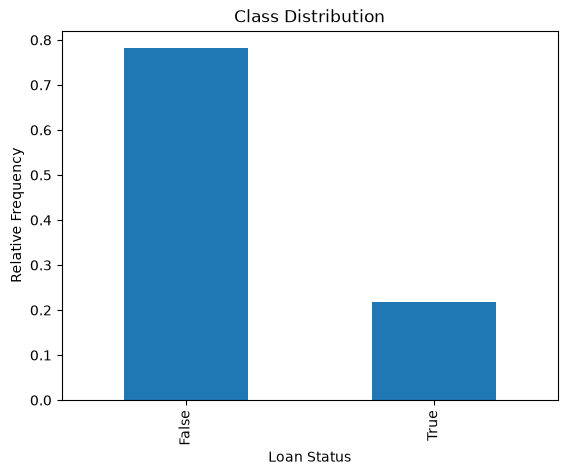

In [10]:
# Plotting the Class Distribution
df.loan_status.value_counts(normalize=True).plot.bar()
#Axes Label
plt.xlabel("Loan Status")
plt.ylabel("Relative Frequency")
#Adding a Title
plt.title("Class Distribution");

The dataset exhibits significant class imbalance. The majority (negative) class, representing loan rejections (False), accounts for 78.18% of the data, while the minority (positive) class, representing approvals (True), makes up only 21.82%. Consequently, rejections occur at nearly 3.6 times the rate of approvals.


# Applicant Demographics

# Age

In [11]:
#Distribution of ages of loan applicants
df.age_group.value_counts()

age_group
Under 25        15352
25-29            8156
30-34            4987
35-39            2321
40-44            1005
45-49             420
50-54             181
55-59              74
60-64              41
65-69              24
70 and Above       20
Name: count, dtype: int64

We see that majority of the loan applicants are between the ages 20 and 44years, we also see a few applicants above age 70. We can visualze this distribution with respect to the loan approval status 

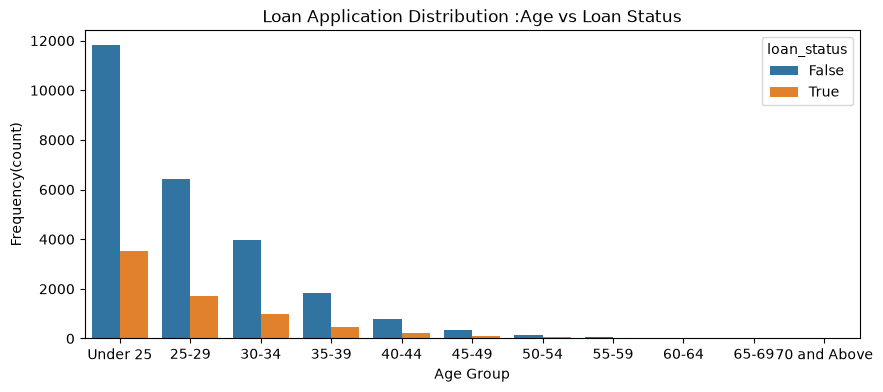

In [12]:
#Bar plot of the age group of the loan applicants
fig,ax=plt.subplots(figsize=(10,4))
sns.countplot(data=df,x="age_group",hue="loan_status")
#Axes label
ax.set_xlabel("Age Group")
ax.set_ylabel("Frequency(count)")
#Title 
plt.title("Loan Application Distribution :Age vs Loan Status");

Most loan applicants are under 30, with the highest volume coming from the Under 25 group. Application numbers drop off significantly for older age brackets.
While the total count of rejections is highest for younger applicants, the actual rejection rate stays steady at around 78–80% across almost every age group. This suggests that age on its own isn't driving higher rejection rates—the high number of young rejections is simply a result of them making up most of the applicant pool. 

# Home Ownership

We want to determine how loan approval relates to home ownership status of the applicants

In [13]:
#Count of applicants home ownership status
df.person_home_ownership.value_counts()

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

A Majority of the loan applicants were individuals living in rental houses, followed by those in morgages. We can visualize the relationship with approval status.

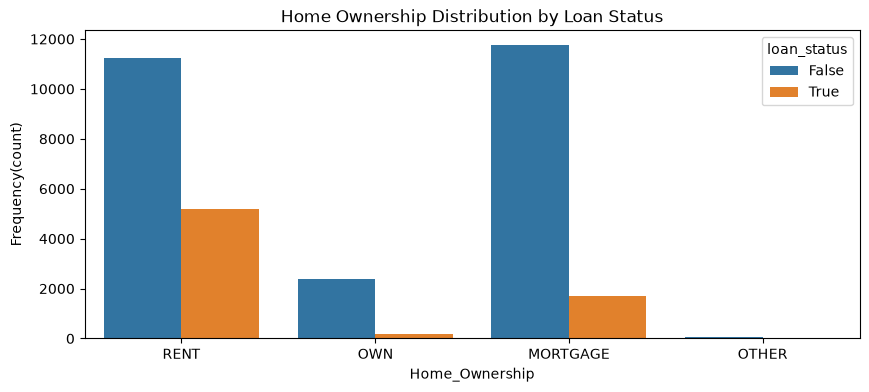

In [14]:
#Bar plot of the age group of the loan applicants
fig,ax=plt.subplots(figsize=(10,4))
sns.countplot(data=df,x="person_home_ownership",hue="loan_status")
#Axes label
ax.set_xlabel("Home_Ownership")
ax.set_ylabel("Frequency(count)")
#Title 
plt.title("Home Ownership Distribution by Loan Status");

Most applicants fall under the RENT and MORTGAGE categories. Interestingly, renters have the highest approval rate, with approvals making up over 30% of their total applications. In contrast, applicants with a mortgage or who own their home face significantly higher rejection rates (around 88% to 92%), despite home ownership typically being associated with financial stability.

# Income
We can visualize the distribution on income across the approval status

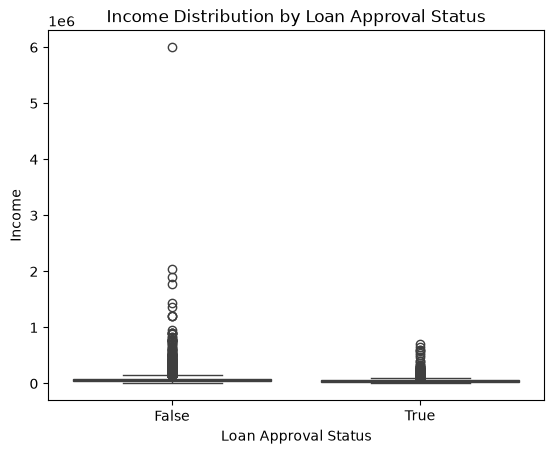

In [15]:
sns.boxplot(data=df,x="loan_status",y="person_income")
plt.ylabel("Income")
plt.xlabel("Loan Approval Status")
plt.title("Income Distribution by Loan Approval Status");

The boxplot doesn't clearly show the quantiles of the income, though we can see that the data has outliers.We'll therefore drop the lower and upper quantiles i.e 10% and 90% respectively of the income column, to give us a better visual of the boxplot

In [16]:
q1,q2=df.person_income.quantile([0.1,0.9])

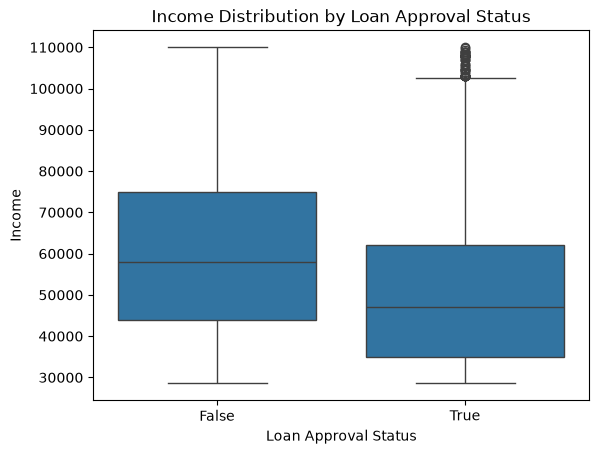

In [17]:
sns.boxplot(data=df[df.person_income.between(q1,q2)],x="loan_status",y="person_income")
plt.ylabel("Income")
plt.xlabel("Loan Approval Status")
plt.title("Income Distribution by Loan Approval Status");

The income distribution for rejected applicants (False) is overall higher than for approved applicants (True), with median incomes of roughly $58,000 and $47,000 respectively. However, approved applications include a noticeable cluster of upper-tail outliers reaching past $100,000. Income by itself appears counterintuitive to approval status here, pointing toward other risk factors at play.

# Historical Default
We want to check the relationship between historical default and loan application

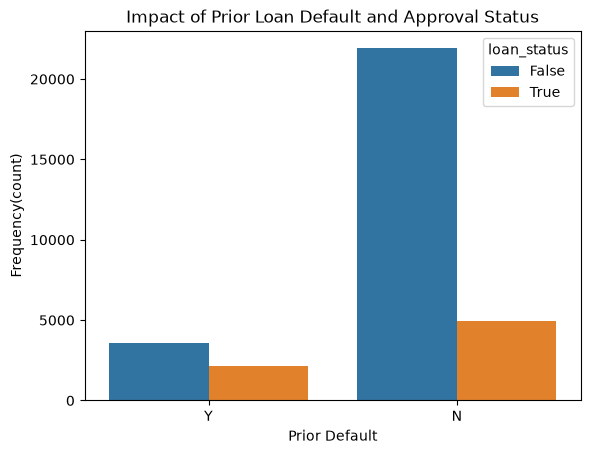

In [18]:
sns.countplot(data=df,x="cb_person_default_on_file",hue="loan_status")
#Axes label
plt.xlabel("Prior Default")
plt.ylabel("Frequency(count)")
#Title 
plt.title("Impact of Prior Loan Default and Approval Status");


Surprisingly, individuals with a history of prior default (Y) show nearly double the approval rate (~37%) of those with no prior default history (N, ~18.5%). Although non-defaulters account for most applications, they face a higher overall rejection proportion, suggesting factors like limited credit history or age play a significant role.

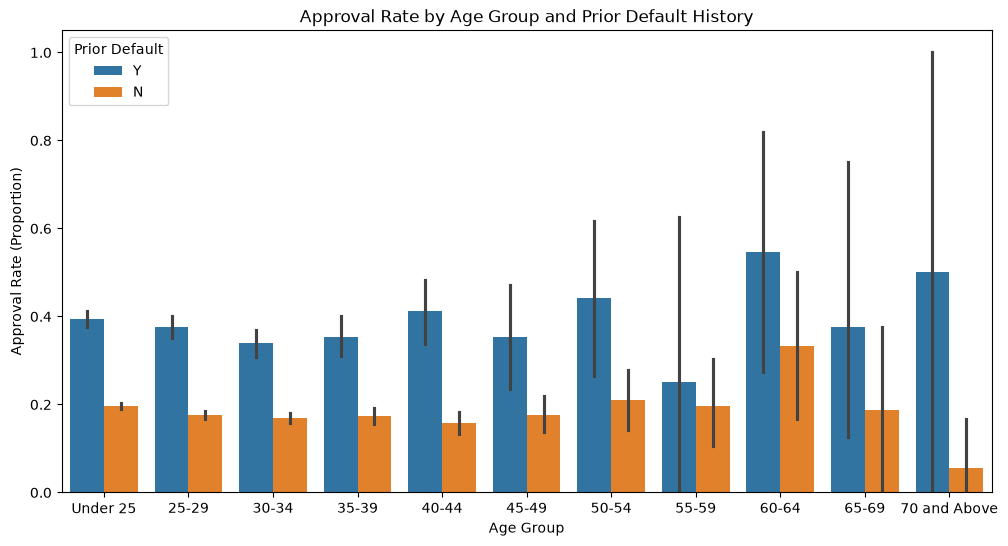

In [19]:
plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df,
    x='age_group',
    y='loan_status',
    hue='cb_person_default_on_file'
    
)
plt.title('Approval Rate by Age Group and Prior Default History')
plt.ylabel('Approval Rate (Proportion)')
plt.xlabel('Age Group')
plt.legend(title='Prior Default')
plt.show()

Across almost all age groups, applicants with a prior default history (Y) surprisingly exhibit a consistently higher loan approval rate than those without a prior default (N). This indicates that age group does not moderate or change the core relationship between prior default history and loan approval.

# Years in Employment
We'll want to see how approval of loans relates with the number of years an applicant has been in employment

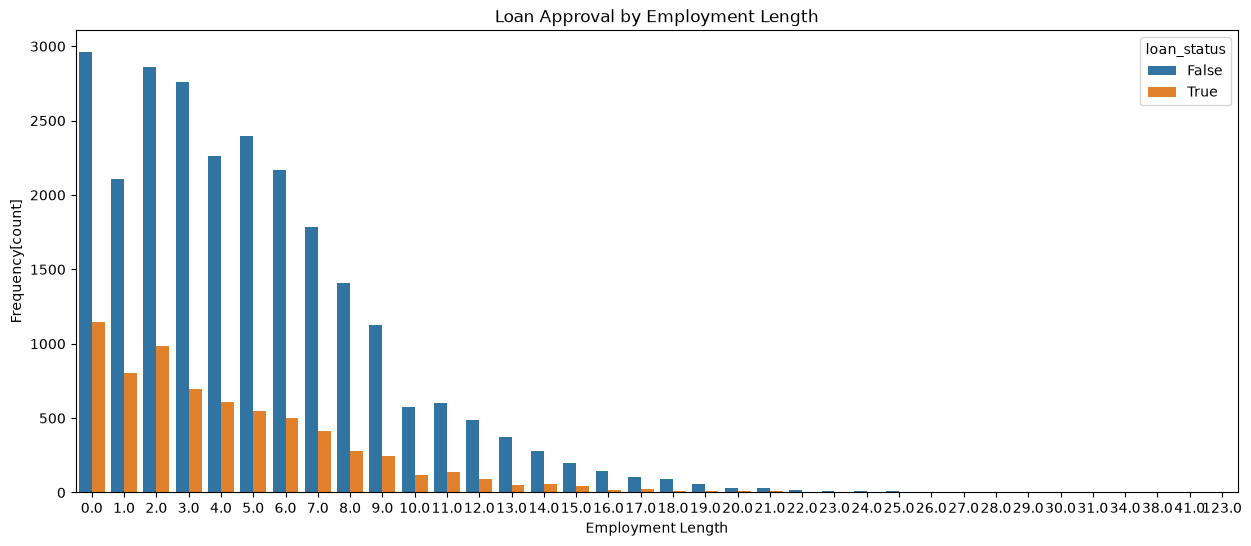

In [20]:
#Plot of Loan Employment Length by Loan Approval Status
fig,ax=plt.subplots(figsize=(15,6))
sns.countplot(data=df,x="person_emp_length",hue="loan_status")
#Label Axes
ax.set_xlabel("Employment Length")
ax.set_ylabel("Frequency[count]")
#Title
plt.title("Loan Approval by Employment Length");

The number of loan applications is right-skewed and inversely related to employment length, with the vast majority of applicants having under 10 years of experience. However, the approval rate remains fairly constant across employment lengths.

# Loan usage(Intention)
We'd want to find out the major reasons the applicants applied for the loans and how the factors relate to the loan approval status

In [21]:
#A normalized horizontal barplot of the loan intention
df.loan_intent.value_counts(normalize=True)


loan_intent
EDUCATION            0.198060
MEDICAL              0.186336
VENTURE              0.175532
PERSONAL             0.169455
DEBTCONSOLIDATION    0.159971
HOMEIMPROVEMENT      0.110647
Name: proportion, dtype: float64

A great proportion of the applicants, applied for loan for Education reasons, followed closely by those who applied for medical reasons.
We find out how this relates to approval status

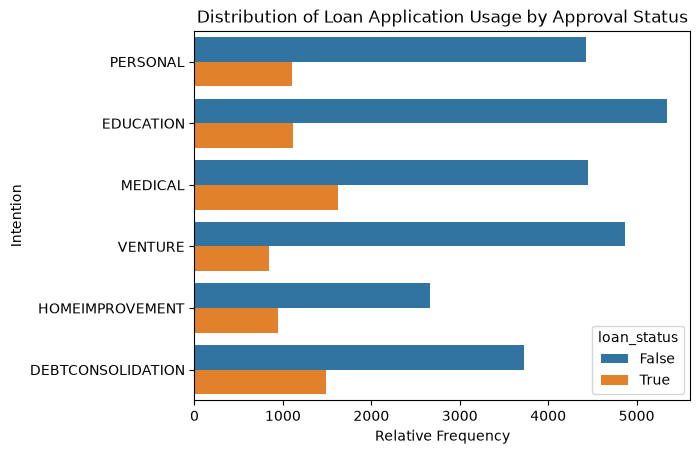

In [22]:
#A horizontal barplot of the loan intention
sns.countplot(data=df,y="loan_intent",hue="loan_status")
#Axes
plt.xlabel("Relative Frequency")
plt.ylabel("Intention")
#Title
plt.title("Distribution of Loan Application Usage by Approval Status");


Loan intent shows clear differences in approval patterns. Applicants seeking loans for Medical expenses and Debt Consolidation achieved both the highest total number of approvals and higher relative approval rates (approaching 28%).
In contrast, loans intended for Venture (business) saw the lowest absolute number of approvals (under 900) alongside a noticeably higher rejection ratio. Lenders appear more willing to approve loans for necessary personal expenditures or debt restructuring than for business ventures.

# Loan Grade
We can check how the different loan grades compare to loan approval status i.e we want to know which grade is more likely to be approved for a loan, then visualize using a barplot in relation to the majority and the minority classes.

In [23]:
df_grade=pd.pivot_table(df,index="loan_grade",values="loan_status",aggfunc=np.mean)
df_grade

,loan_status
loan_grade,
A,0.099564
B,0.162760
C,0.207340
D,0.590458
E,0.644191
F,0.705394
G,0.984375


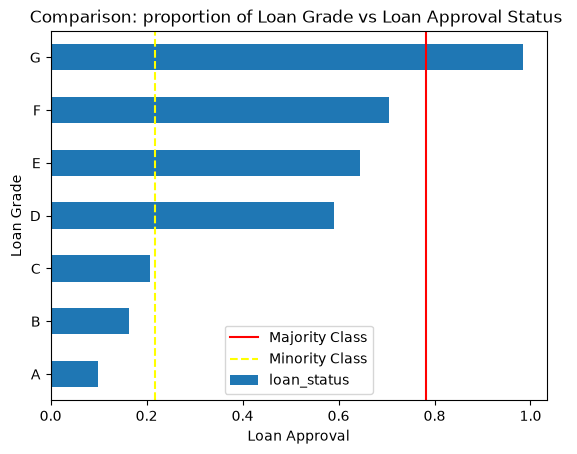

In [24]:
#Horizontal plot
df_grade.plot.barh()
#Axes
plt.xlabel("Loan Approval")
plt.ylabel("Loan Grade")
#Adding Vertical class
plt.axvline(majority,color="red",linestyle="-",label="Majority Class")
plt.axvline(minority,color="yellow",linestyle="--",label="Minority Class")
#title
plt.title("Comparison: proportion of Loan Grade vs Loan Approval Status ")
plt.legend();


Loan Grade A has the highest likelihood of approval approx 90%, while risk scales up progressively through Grades B to G, where Grade G exhibits near total default risk (~98%).

# Credit History Length

In [25]:
credit_history=df.groupby("cb_person_cred_hist_length")["loan_status"].mean().sort_index().to_frame()
credit_history.head()

,loan_status
cb_person_cred_hist_length,
2,0.235708
3,0.222783
4,0.223122
5,0.206273
6,0.207862


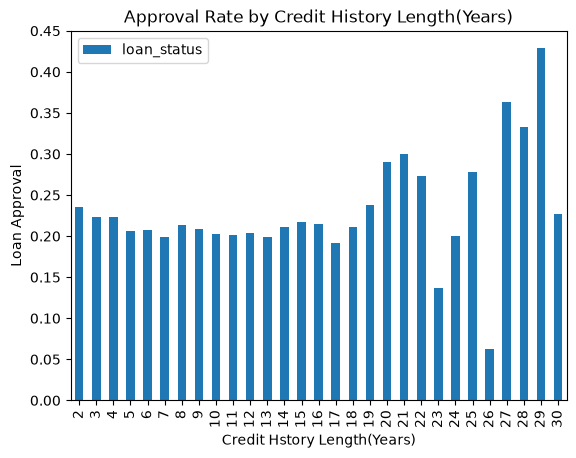

In [26]:
#plotting the bar plot
credit_history.plot.bar()
#Axes label
plt.xlabel("Credit Hstory Length(Years)")
plt.ylabel("Loan Approval")
#Title
plt.title("Approval Rate by Credit History Length(Years)");

Between 2 and 18 years of credit history, the approval rate remains remarkably flat, holding steady around the 20–22% baseline.
Beyond 19 years, approval rates begin trending upward, peaking above 40% for applicants with nearly 30 years of history. The erratic spikes and drops in the upper tail (such as years 23 and 27) are primarily due to small sample sizes in older age brackets rather than a drop in creditworthiness.

# Loan Amount

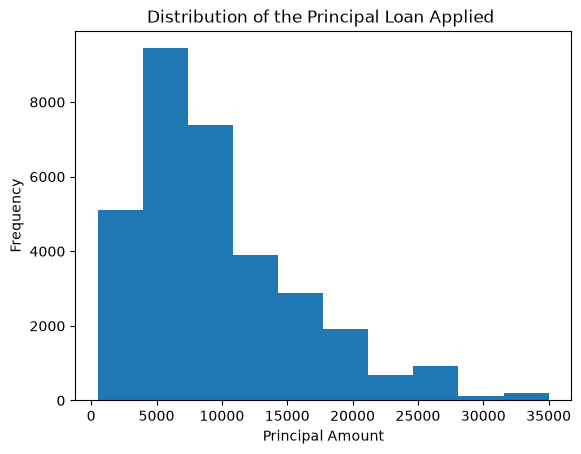

In [27]:
#Histogram of loan Amount
plt.hist(df.loan_amnt)
#Axes label
plt.xlabel("Principal Amount")
plt.ylabel("Frequency")
#title
plt.title("Distribution of the Principal Loan Applied ");

The distribution of requested principal loan amounts is strongly right-skewed, with the majority of applicants seeking between 5,000 and 10,000. Beyond 15,000, demand drops off significantly, though small localized spikes occur at round amount such as 25,000 and 35,000.

We'll assess the relationship between loan amount and loan percentage income

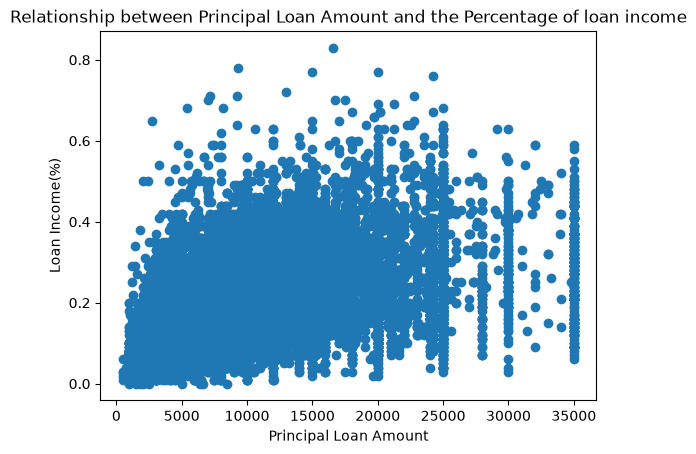

In [28]:
#Scatter Plot
plt.scatter(x=df.loan_amnt,y=df.loan_percent_income)
#Axes Labels
plt.ylabel("Loan Income(%)")
plt.xlabel("Principal Loan Amount")
#Title
plt.title("Relationship between Principal Loan Amount and the Percentage of loan income");


There is a strong positive non-linear relationship between Principal Loan Amount and Loan Percent Income. While smaller loans consistently represent a minor fraction of income (< 30%), larger loan amounts show significantly higher deviations and regularly reach up to 60%–70% of income, bounded by a sharp risk cap above 80%.

# Correlation
We can determine how the numeric variables correlate

In [29]:
df.select_dtypes("number").corr()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
person_income,1.000000,0.134268,0.266820,0.000792,-0.254471,0.117987
person_emp_length,0.134268,1.000000,0.113082,-0.056405,-0.054111,0.144699
loan_amnt,0.266820,0.113082,1.000000,0.146813,0.572612,0.041967
loan_int_rate,0.000792,-0.056405,0.146813,1.000000,0.120314,0.016696
loan_percent_income,-0.254471,-0.054111,0.572612,0.120314,1.000000,-0.031690
cb_person_cred_hist_length,0.117987,0.144699,0.041967,0.016696,-0.031690,1.000000


Most numerical features display weak linear correlations, with interest rate and applicant income showing near-zero correlation (+0.0008). However, a moderate-to-strong positive correlation exists between loan_amnt and loan_percent_income (+0.573), alongside a moderate negative correlation between person_income and loan_percent_income (-0.254), reflecting the underlying mathematical relationship of the debt-to-income ratio.

# High Cardinality
We'll drop the features with high cardinality, which will prove redundant to the model

In [30]:
df.drop(columns="loan_status").select_dtypes(exclude="number").nunique()

person_home_ownership         4
loan_intent                   6
loan_grade                    7
cb_person_default_on_file     2
age_group                    11
dtype: int64

We'll keep all our categorical variables

# Spliting

In [31]:
#Choosing the target and feature variables
target="loan_status"
X=df.drop(columns="loan_status")
y=df[target]

# Training The Data
We'll use 80% of the data for the training set, and 20% for the test data

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
#Checking whether X_train has the same number of columns as the feature matrix 
assert X_train.shape[1]==X.shape[1]
#Checking whether y_train returns a series
assert isinstance(y_train,pd.Series)

# Model Building
We'll build a Gradient Boosting Model for our data as it is more robust and since it builds decision trees sequentially, this ensures that the residual errors are minimized leading to higher precision

# Baseline
The first step in Modelling our data is to determine the Baseline, using the DummyClassifier Class. This acts as a benchmark for our model performance.

In [34]:
#Instantiate and fit the Dummy Classifier 
dummy = DummyClassifier(strategy="stratified",random_state=42)
dummy.fit(X_train, y_train)

#Predict classes and probabilities
y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

#Print the metrics
print("=== Baseline Dummy Classifier Performance ===")
print(classification_report(y_test, y_pred_dummy))
print(f"Baseline ROC-AUC: {round(roc_auc_score(y_test, y_proba_dummy),2)}")


=== Baseline Dummy Classifier Performance ===
              precision    recall  f1-score   support

       False       0.78      0.79      0.78      5072
        True       0.23      0.23      0.23      1445

    accuracy                           0.66      6517
   macro avg       0.51      0.51      0.51      6517
weighted avg       0.66      0.66      0.66      6517

Baseline ROC-AUC: 0.51


We have a baseline accuracy of 0.66, which is the accuracy that the model accurately predicts the majority class and a baseline ROC-AUC of 0.51 meaning that the baseline model is more based on randomness.

# Iterating

We'll create a pipeline with Simple imputer(), to help in the imputation of the missing data in the columns, we'll also use OrdinalEncoder() from category-encoders to handle the categorical data types. 

In [35]:
#Initializing the pipeline
clf=make_pipeline(OrdinalEncoder(),SimpleImputer(),GradientBoostingClassifier(random_state=42))


In [36]:
params={"simpleimputer__strategy":["mean","median"],
        "gradientboostingclassifier__max_depth":range(2,5),
        "gradientboostingclassifier__n_estimators":range(25,31,5)}

In [37]:
#Compute class weights for y_train for class balance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
#Performing a Grid search Crossvalidation for the best parameter of our model
model=GridSearchCV(clf,param_grid=params,cv=5,n_jobs=-1,verbose=1)
#Fit the model
model.fit(X_train,y_train,gradientboostingclassifier__sample_weight=sample_weights)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\user\anaconda3\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gradientboostingclassifier__max_depth': range(2, 5), 'gradientboostingclassifier__n_estimators': range(25, 31, 5), 'simpleimputer__strategy': ['mean', 'median']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

We can check the best parameters i.e the best fit model out of all the models in the Grid search

In [38]:
#Best parameters
model.best_params_

{'gradientboostingclassifier__max_depth': 4,
 'gradientboostingclassifier__n_estimators': 30,
 'simpleimputer__strategy': 'mean'}

# Model Evaluation
We will evaluate the y_test on the model to determine the model's generalizability

In [39]:
#Make predictions
y_test_predict=model.predict(X_test)
y_test_predict

array([False, False, False, ..., False, False, False], shape=(6517,))

In [40]:
y_test_predict_proba=model.predict_proba(X_test)
y_test_predict_proba

array([[0.77200854, 0.22799146],
       [0.50588385, 0.49411615],
       [0.50452838, 0.49547162],
       ...,
       [0.83878054, 0.16121946],
       [0.82395592, 0.17604408],
       [0.73002971, 0.26997029]], shape=(6517, 2))

In [41]:
#Print the metrics
print("=== Gradient Boosting Classifier Model Performance ===")
print(classification_report(y_test, y_test_predict))
print(f"Model ROC-AUC: {round(roc_auc_score(y_test, y_test_predict_proba[:, 1]),2)}")
                      

=== Gradient Boosting Classifier Model Performance ===
              precision    recall  f1-score   support

       False       0.93      0.92      0.93      5072
        True       0.74      0.76      0.75      1445

    accuracy                           0.89      6517
   macro avg       0.84      0.84      0.84      6517
weighted avg       0.89      0.89      0.89      6517

Model ROC-AUC: 0.92


The Gradient Boosting Classifier demonstrated strong generalization on the unseen test set, achieving an overall accuracy of 89% and an ROC-AUC of 0.92 (a great improvement from the baseline ROC-AUC of 0.51).

For the minority positive class (True), the model achieved a precision of 0.74 (up from the baseline of 0.23) and a recall of 0.76 (up from 0.23). This indicates that when predicting a positive instance, the model is accurate 74% of the time, while successfully capturing 76% of all actual positive cases in the dataset 

We'll plot a confusion matrix to help us visualize the model's performance.

In [42]:
confusion_mat=confusion_matrix(y_test,y_test_predict)
confusion_mat

array([[4682,  390],
       [ 340, 1105]])

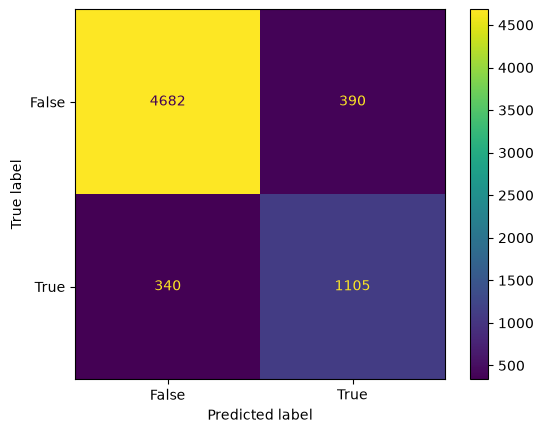

In [43]:
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test);

The confusion matrix demonstrates strong class separation on the test set. Out of 1,445 actual positive cases, the model correctly identified 1,105 True Positives while limiting False Negatives to 340. Furthermore, out of 5,072 actual negative cases, 4,682 were correctly classified as True Negatives with only 390 False Positives.

# Communicating the Results

In [44]:
model.best_estimator_.named_steps.gradientboostingclassifier.feature_importances_

array([1.58877696e-01, 8.40981375e-02, 1.95149397e-02, 4.53151565e-02,
       1.24819639e-01, 1.92424588e-03, 2.43366889e-01, 3.21476876e-01,
       6.77118080e-16, 9.84643725e-05, 5.07955293e-04])

We extract the feature importances from the model, and make a horizontal bar plot

In [45]:
#Extracting the feature importance and converting to a series
feat_imp=pd.Series(model.best_estimator_.named_steps.gradientboostingclassifier.feature_importances_,index=X_test.columns)
feat_imp

person_income                 1.588777e-01
person_home_ownership         8.409814e-02
person_emp_length             1.951494e-02
loan_intent                   4.531516e-02
loan_grade                    1.248196e-01
loan_amnt                     1.924246e-03
loan_int_rate                 2.433669e-01
loan_percent_income           3.214769e-01
cb_person_default_on_file     6.771181e-16
cb_person_cred_hist_length    9.846437e-05
age_group                     5.079553e-04
dtype: float64

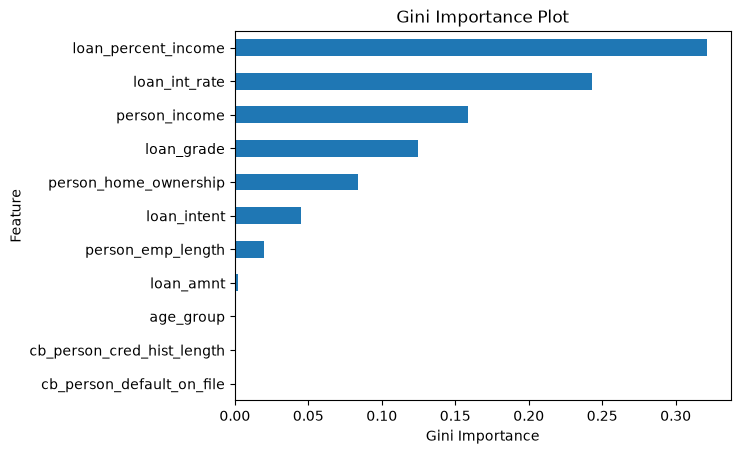

In [46]:
#Barplot
feat_imp.sort_values().plot.barh()
#Axes Label
plt.xlabel("Gini Importance")
plt.ylabel("Feature")
#Title
plt.title("Gini Importance Plot");

The Gini importance plot illustrates the relative contribution of each feature to the model's decision-making process, measured by the total reduction in impurity across all boosting iterations.

loan_percent_income and loan_int_rate emerged as the primary drivers of credit risk predictions, followed by person_income and loan_grade. Features near the bottom, such as loan_amnt and age_group, contributed minimally to splitting nodes.

In [50]:
public_url=f"[https://localhost:9000](https://localhost:9000)"

In [56]:
app.run(host="localhost",port=9000,jupiter_server_url=public_url)